In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# MachineMoo Imports
from machinemoo.scalarization.examples.logistic_fair import LogRegScalarization
from machinemoo.scalarization.lipschitz_estimation import calculate_logreg_lipschitz_constant
from machinemoo.moo.random_weights import RandomWeights
from machinemoo.moo.monise import Monise
from machinemoo.moo.moo_handler import get_objectives

# Utils
from machinemoo.analysis.decision import filter_dominated
# If you have the metrics module ready
# from machinemoo.analysis.metrics import compute_hypervolume_progress 

In [2]:
# Load dataset
# Ensure the path is correct relative to your notebook
df = pd.read_csv('dataset/compas_onerace.csv')

# Drop unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Define features
fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

print(f"Dataset loaded. Shape: {df.shape}")

# Preprocessing
X = df.drop([pred_feature], axis=1)
# Normalize target to 0/1 (if not already)
y = (df[pred_feature] + 1) // 2 

# Stratified split to maintain class/group balance
# Create a stratification key based on target + sensitive attribute
stratify_col = y.astype(str) + "_" + X[fair_feature].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, # As per your original notebook
    stratify=stratify_col,
)

# Scaling is important for Logistic Regression convergence
scaler = StandardScaler()
# Keep as DataFrames to preserve column names for LogRegScalarization
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
# Restore the binary sensitive feature to 0/1 (scaling might have shifted it)
# This is crucial because LogRegScalarization uses unique values of fair_feat
X_train[fair_feature] = X.loc[X_train.index, fair_feature]

X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
X_test[fair_feature] = X.loc[X_test.index, fair_feature]

print(f"Training set size: {len(X_train)}")

Dataset loaded. Shape: (6172, 7)
Training set size: 4320


In [3]:
print("Calculating Lipschitz Constants...")
# Define masks for your groups
mask_white = (X_train['not_white'] == 0)
mask_non_white = (X_train['not_white'] == 1)

# Calculate L for each objective (Group 0, Group 1)
L0 = calculate_logreg_lipschitz_constant(X_train[mask_white].values)
L1 = calculate_logreg_lipschitz_constant(X_train[mask_non_white].values)
lipschitz_vector = np.array([L0, L1])

print(f"Lipschitz Constants: {lipschitz_vector}")

Calculating Lipschitz Constants...
Lipschitz Constants: [0.38722446 0.3925618 ]


In [4]:
def run_experiment(name, optimizer_cls, scalarizer_params, opt_params):
    print(f"\n--- Running {name} ---")
    
    # 1. Initialize Scalarization
    # We create a fresh instance for each run to avoid state leakage
    scalarizer = LogRegScalarization(
        num_objs=2,
        X=X_train,
        y=y_train,
        fair_feat='not_white',
        **scalarizer_params
    )
    
    # 2. Initialize Optimizer
    optimizer = optimizer_cls(
        weighted_scalar=scalarizer,
        single_scalar=scalarizer, # Use same logic for single objs
        verbose=False, # Keep log cleaner
        **opt_params
    )
    
    # 3. Run
    optimizer.optimize()
    
    # 4. Extract Results
    objs = get_objectives(optimizer)
    
    # Optional: clean dominated solutions for fair comparison
    objs, _ = filter_dominated(objs)
    
    print(f"Found {len(objs)} non-dominated solutions.")
    return {
        "name": name,
        "objectives": objs,
        "optimizer": optimizer,
        "runtime": optimizer.fit_runtime
    }

In [5]:
results = {}
common_opt_params = {
    'target_size': 10000000000,
    'time_limit': 30, 
}

common_scalarizer_params = {
    # Any common params can go here
    'max_iter': 1,
    'tol': 1e-4
}

# 1. Random Weights (Baseline)
results['RW'] = run_experiment(
    "Random Weights",
    RandomWeights,
    scalarizer_params= common_scalarizer_params | {'lower_bound_estimate': "zero"}, # Strategy doesn't matter for RW, just training
    opt_params=common_opt_params
)

# 2. MONISE (Standard / Zero Estimate)
# Uses standard global lower bounds (Utopia point)
results['Monise-Zero'] = run_experiment(
    "MONISE (Zero)",
    Monise,
    scalarizer_params= common_scalarizer_params | {'lower_bound_estimate': "zero"},
    opt_params={**common_opt_params, 'node_gap': 0.01}
)

# 3. MONISE (Lipschitz Estimate)
# Uses tighter lower bounds derived from gradients
results['Monise-Lip'] = run_experiment(
    "MONISE (Lipschitz)",
    Monise,
    # We pass the pre-calculated L vector here
    scalarizer_params=common_scalarizer_params | {
        'lower_bound_estimate': "lipschitz",
        #'lipschitz_constants': lipschitz_vector
    },
    opt_params={**common_opt_params, 'node_gap': 0.01, 'node_time_limit': 2.0}
)


--- Running Random Weights ---


/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stab

Found 351 non-dominated solutions.

--- Running MONISE (Zero) ---
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06


/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stab

Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06


...

/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06


/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Found 46 non-dominated solutions.


/home/marcos/.pyenv/versions/machinemoo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


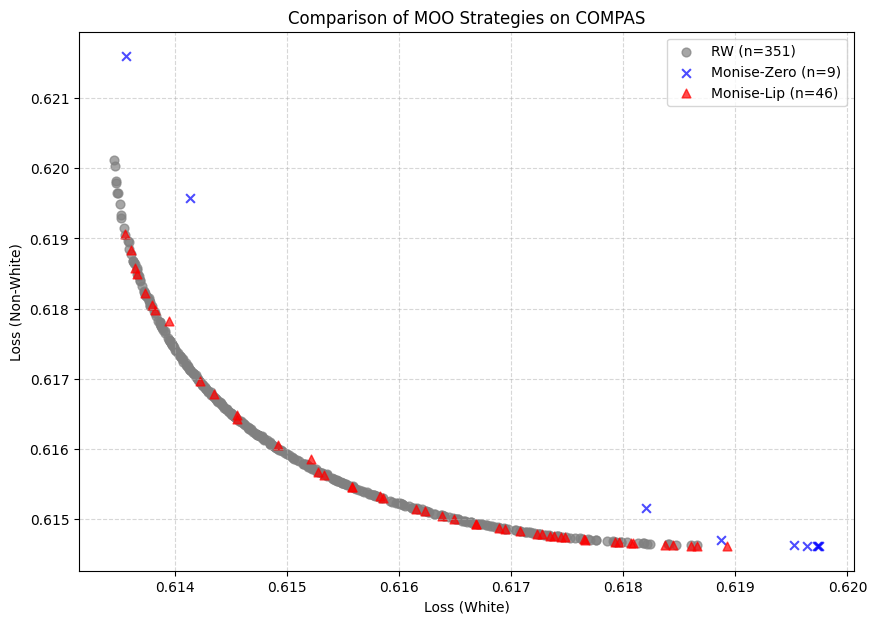


Runtime Comparison:
RW: 30.02 s
Monise-Zero: 2.73 s
Monise-Lip: 12.03 s


In [16]:
plt.figure(figsize=(10, 7))

colors = {'RW': 'gray', 'Monise-Zero': 'blue', 'Monise-Lip': 'red'}
markers = {'RW': 'o', 'Monise-Zero': 'x', 'Monise-Lip': '^'}

for key, res in results.items():
    objs = res['objectives']
    plt.scatter(
        objs[:, 0], objs[:, 1], 
        label=f"{key} (n={len(objs)})", 
        c=colors[key], marker=markers[key], s=40, alpha=0.7
    )

plt.xlabel('Loss (White)')
plt.ylabel('Loss (Non-White)')
plt.title('Comparison of MOO Strategies on COMPAS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Print Runtimes
print("\nRuntime Comparison:")
for key, res in results.items():
    print(f"{key}: {res['runtime']:.2f} s")

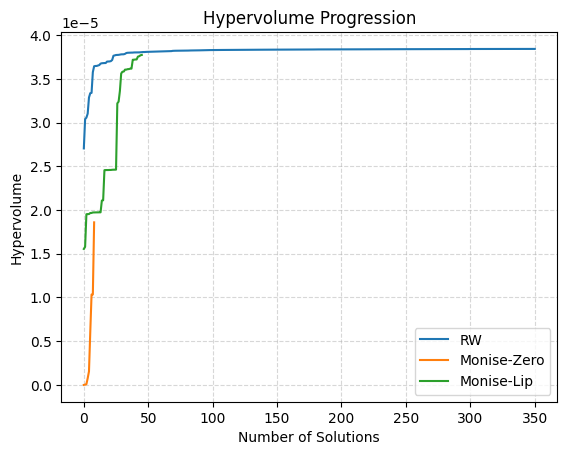

In [17]:
from machinemoo.analysis.metrics import compute_hypervolume_progress

reference_point = np.array([-np.inf, -np.inf])  # Adjust based on your objective scales
for key, res in results.items():
    objs = res['objectives']
    reference_point = np.maximum(reference_point, objs.max(axis=0))

for key, res in results.items():
    objs = res['objectives']
    hv_values = compute_hypervolume_progress(objs, reference_point)
    plt.plot(hv_values, label=key)

plt.xlabel('Number of Solutions')
plt.ylabel('Hypervolume')
plt.title('Hypervolume Progression')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [18]:
monise__ = results['Monise-Lip']

In [19]:
index = np.argmin(monise__['objectives'][:,0])

In [20]:
optimizer = monise__['optimizer']

In [21]:
optimizer.solutions_list[index].objective(), optimizer.solutions_list[index].objs_lb , np.linalg.norm(optimizer.solutions_list[index].gradient, axis=1)**2

(array([0.61355834, 0.61906444]),
 array([0.61355679, 0.61906433]),
 array([4.58498555e-05, 2.11199309e-03]))

In [22]:
w = optimizer.solutions_list[index].w
grads = optimizer.solutions_list[index].gradient
L = lipschitz_vector
w_gradient = w @ grads
w_L = w @ L

In [23]:
from scipy.optimize import minimize

def solve_optimal_w(grads, L, epsilon=1e-8):
    """
    Finds w that minimizes (w_grads @ w_grads) / (w @ L)
    subject to w being a simplex.
    """
    n_obj = len(L)
    
    # Precompute Gram Matrix M = G @ G.T (Shape: n_obj x n_obj)
    # This represents the dot products between all pairs of objective gradients.
    M = grads @ grads.T

    def objective(w):
        # Numerator: w^T M w
        # This is equivalent to || w @ grads ||^2
        numerator = w @ M @ w
        
        # Denominator: w @ L
        denominator = w @ L
        
        return numerator / (denominator + epsilon)

    # Jacobian of the objective (optional, speeds up convergence)
    def jacobian(w):
        num = w @ M @ w
        den = w @ L + epsilon
        
        # d/dw (N/D) = (D * N' - N * D') / D^2
        # N' = 2Mw (gradient of quadratic form)
        # D' = L   (gradient of linear form)
        grad_num = 2 * (M @ w)
        grad_den = L
        
        return (den * grad_num - num * grad_den) / (den**2)

    # Constraints: sum(w) = 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    
    # Bounds: 0 <= w <= 1
    bounds = tuple((0.0, 1.0) for _ in range(n_obj))
    
    # Initial guess: Uniform distribution
    w0 = np.ones(n_obj) / n_obj
    
    result = minimize(
        objective, 
        w0, 
        method='SLSQP', 
        jac=jacobian,
        bounds=bounds, 
        constraints=constraints,
        options={'ftol': 1e-9, 'disp': False}
    )
    
    return result.x

In [24]:
w_gradient = w @ grads
w_L = w @ L
print('w',w)
-1/w_L*grads@w_gradient + L/(2*w_L**2)*(w_gradient@w_gradient)

w [0.87304838 0.12695162]


array([-1.54222874e-06, -1.09356814e-07])

In [25]:
new_w = solve_optimal_w(grads, L)
new_w_gradient = new_w @ grads
new_w_L = new_w @ L
print('new_w',new_w)
-1/new_w_L*grads@new_w_gradient + L/(2*new_w_L**2)*(new_w_gradient@w_gradient)

new_w [0.87304838 0.12695162]


array([-1.54222874e-06, -1.09356814e-07])